## Machine Learning (S2-25_DSECLZG565)
### Assignment - 2
### BITS ID: 2025DAO4046

### Multi-Class Classification of Obesity Levels Based on Eating Habits and Physical Condition

In [1]:
# Loading the data from UCI Machine Learning Repository
import pandas as pd

uci_data_url = "https://archive.ics.uci.edu/static/public/544/data.csv"
obesity_df = pd.read_csv(uci_data_url)
obesity_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
# Observing the dataset information
obesity_df.info()
obesity_df['NObeyesdad'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [3]:
# Cleaning and integrity check of the data

# Identification of missing values
print("Missing values per column:")
print(obesity_df.isnull().sum())
print()

# Removal of duplicates
dup_count = obesity_df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
obesity_df = obesity_df.drop_duplicates()
print(f"Shape after removing duplicates: {obesity_df.shape}")
print()

# Finding summary statistics
print("Summary statistics (numeric columns):")
print(obesity_df.describe())
print()
print("Summary statistics (categorical columns):")
print(obesity_df.describe(include='object'))
print()

# Correcting the data types
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in numeric_cols:
    if col in obesity_df.columns:
        obesity_df[col] = pd.to_numeric(obesity_df[col], errors='coerce')

print("Data types after correction:")
print(obesity_df.dtypes)

Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Duplicate rows found: 24
Shape after removing duplicates: (2087, 17)

Summary statistics (numeric columns):
               Age       Height       Weight         FCVC          NCP  \
count  2087.000000  2087.000000  2087.000000  2087.000000  2087.000000   
mean     24.353090     1.702674    86.858730     2.421466     2.701179   
std       6.36880

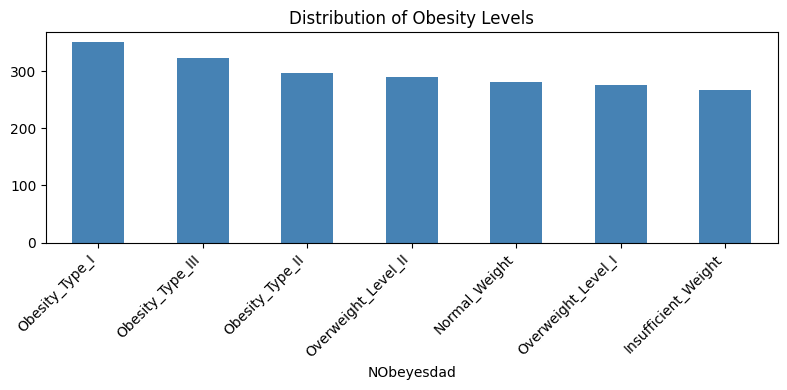

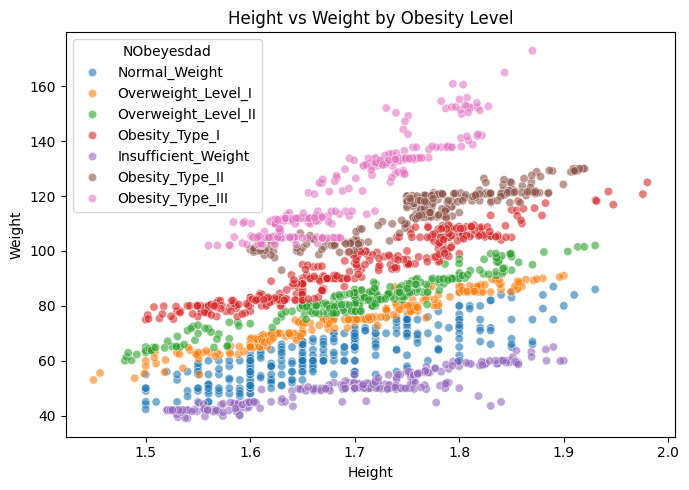

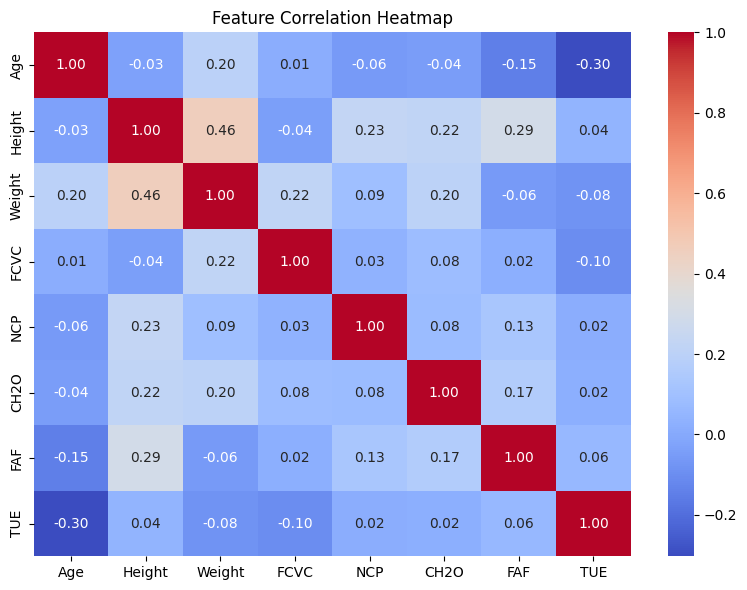

In [4]:
# Exploring the dataset using Univariate, Bivariate, and Multivariate analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate analysis (balancing target class)
plt.figure(figsize=(8, 4))
obesity_df['NObeyesdad'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Obesity Levels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bivariate analysis
plt.figure(figsize=(7, 5))
sns.scatterplot(data=obesity_df, x='Height', y='Weight', hue='NObeyesdad', alpha=0.6)
plt.title('Height vs Weight by Obesity Level')
plt.tight_layout()
plt.show()

# Multivariate analysis for numeric features
plt.figure(figsize=(8, 6))
numeric_obesity_df = obesity_df.select_dtypes(include='number')
sns.heatmap(numeric_obesity_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [5]:
# Preprocessing of the dataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing
obesity_df_train, obesity_df_test = train_test_split(
    obesity_df, test_size=0.2, random_state=42, stratify=obesity_df['NObeyesdad']
)

# Saving the test data in local storage
obesity_df_test.to_csv('test_data.csv', index=False)

# Encoding both splits using encoders
obesity_df_train_encoded = obesity_df_train.copy()
obesity_df_test_encoded = obesity_df_test.copy()

cat_cols = obesity_df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('NObeyesdad')

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    obesity_df_train_encoded[col] = le.fit_transform(obesity_df_train[col])
    obesity_df_test_encoded[col] = le.transform(obesity_df_test[col])
    encoders[col] = le

target_encoder = LabelEncoder()
obesity_df_train_encoded['NObeyesdad'] = target_encoder.fit_transform(obesity_df_train['NObeyesdad'])
obesity_df_test_encoded['NObeyesdad'] = target_encoder.transform(obesity_df_test['NObeyesdad'])

X_train = obesity_df_train_encoded.drop('NObeyesdad', axis=1)
y_train = obesity_df_train_encoded['NObeyesdad']
X_test = obesity_df_test_encoded.drop('NObeyesdad', axis=1)
y_test = obesity_df_test_encoded['NObeyesdad']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Training of all models, saving the models, and calculating required metrics upon their performance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, matthews_corrcoef)
import joblib, os

os.makedirs('model/saved_models', exist_ok=True)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1": f1_score(y_test, y_pred, average='macro'),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }
    joblib.dump(model, f"model/saved_models/{name.replace(' ', '_')}.pkl")

joblib.dump(scaler, "model/saved_models/scaler.pkl")
joblib.dump(encoders, "model/saved_models/encoders.pkl")
joblib.dump(target_encoder, "model/saved_models/target_encoder.pkl")

results_obesity_df = pd.DataFrame(results).T
results_obesity_df

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.889952,0.985214,0.887185,0.886746,0.883593,0.872398
Decision Tree,0.925837,0.955308,0.924302,0.922929,0.923267,0.913451
KNN,0.808612,0.942907,0.792724,0.801105,0.786393,0.779662
Naive Bayes,0.598086,0.886652,0.620414,0.593190,0.559499,0.548186
Random Forest,0.954545,0.997317,0.954836,0.952813,0.953126,0.947138
